### Québriac Jeanne 21302745

# Mini-projet 5: Le réchauffement climatique

Le but ici est de savoir si des mesures de température mesurées localement au cours du dernier siècle mettent en évidence un réchauffement significatif.

Pour cela, on s'aidera des relevés de température enregistrés quotidiennement depuis juin 1920 à la station météorologique de Montélimar.

On utilisera donc le fichier *montelimar_temperature.dat* correspondant à ces relevés:
- colonne 1 : date en MJD (*modified Julian Day*)
- colonne 2 : température en degrés Celsius


### On importe les bibliothèques utiles

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.optimize as sc

## Partie 1: Représenter l'effet du réchauffement climatique avec les données du fichier

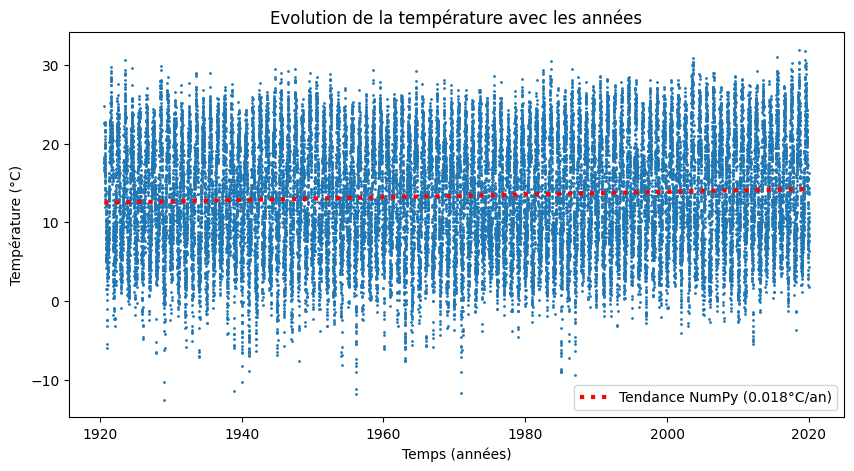

In [3]:
#Import les données et on les sauvegarde
montelimar=np.loadtxt("montelimar_temperature.dat")

# On extrait les données de la températures et du temps
date=montelimar[:,0]
temperatures=montelimar[:,1]
annees=1858.878+date/365.25   #On convertit la date en années

# Ajustement linéaire
coeffs = np.polyfit(annees, temperatures, 1)  # ajuste un polynôme de degré 1 aux données et retourne les coefficients de ce polynôme
trend_numpy = np.polyval(coeffs, annees)  # évalue le polynôme ajusté pour chaque année


plt.figure(figsize=(10, 5))
plt.plot(annees,temperatures,'.', markersize=2)
plt.plot(annees, trend_numpy, color="red", linestyle="dotted", linewidth=3, label=f"Tendance NumPy ({coeffs[0]:.3f}°C/an)")
plt.title("Evolution de la température avec les années")
plt.xlabel("Temps (années)")
plt.ylabel("Température (°C)")
plt.legend()

In [4]:
print("Augmentation moyenne de la température sur 100 ans: ",coeffs[0]*100)

Augmentation moyenne de la température sur 100 ans:  1.7530195464929


L'effet du réchauffement climatique se remarque seulement sur une longue période car par années l'augmentation de la température est de l'ordre d'un centième ce qui montre que le réchauffement climatique à un effet faible et lent. Par exemple, sur 100 ans l'augmentation est à peine de 2°C.

## Partie 2: Montrer à l'aide d'un modèle que l'augmentation des températures ne correspond pas à une fluctuation statistique

Pour cela on supposera que l'erreur sur les mesures de température est de l'ordre de 5 °C,  l'ordre de grandeur des fluctuations quotidiennes.

L'ajustement utilisé est un ajustement sinusoïdal pour chaque décennie:

$$ T(t) = A \sin{(\omega t + \phi)} + B + C t $$

où les paramètres $A$ (amplitude), $\phi$ (phase) et $B$ (température moyenne) et $C$ (accroissement linéaire lent de la température) doivent être ajustés aux données et $\omega = 2\pi/1\text{ an}.$

On a supposé que l'accroissement lent de la température est linéaire pour affiner le modèle.

L'idée est de voir si le paramètre $B$ (température moyenne) augmente en appliquant un ajustement sinusoïdal pour chaque décennie, et voir si le paramètre $B$ (température moyenne) augmente.

A ajusté:  9.009212779781215 ± 0.03713774242987342
phi ajusté:  -1.8885401764596241 ± 0.004117411754894894
B ajusté:  -19.8584690359318 ± 1.802796828769031
C ajusté:  0.016863760881221372 ± 0.0009148842121948621


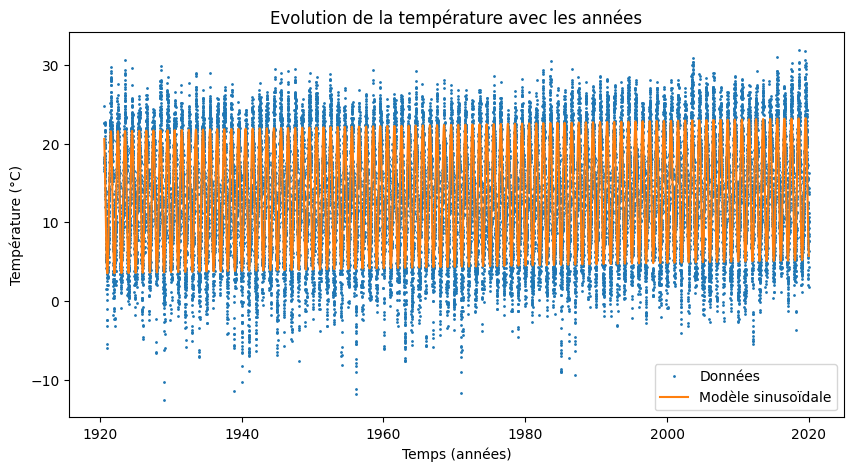

In [9]:
# On regarde tout d'abord l'évolution des températures sur tout le siècle avec l'ajustement
def modele(t,a,phi,b,c):
    omega=2*np.pi
    return a*np.sin(omega*t+phi)+b+c*t

erreur=np.ones(temperatures.shape)*5

params, covar = sc.curve_fit(modele,annees,temperatures,sigma=erreur,absolute_sigma=True)
errors=np.sqrt(np.diag(covar))

print("A ajusté: ",params[0],"±", errors[0])
print("phi ajusté: ",params[1],"±", errors[1])
print("B ajusté: ", params[2],"±", errors[2])
print("C ajusté: ", params[3],"±", errors[3])

plt.figure(figsize=(10,5))
plt.plot(annees,temperatures,'.', markersize=2,label="Données")
plt.plot(annees,modele(annees,params[0],params[1],params[2],params[3]),label="Modèle sinusoïdale")
plt.title("Evolution de la température avec les années")
plt.xlabel("Temps (années)")
plt.ylabel("Température (°C)")
plt.legend()

L'ajustement utilisé fit bien les données, le modèle est correct. Néanmoins on remarque que les paramètres ajustés sont totalement faux, par exemple, la température moyenne donnée n'est même pas dans l'interval des valeurs du fichier. Je ne trouve pas de réponses à ce problème.

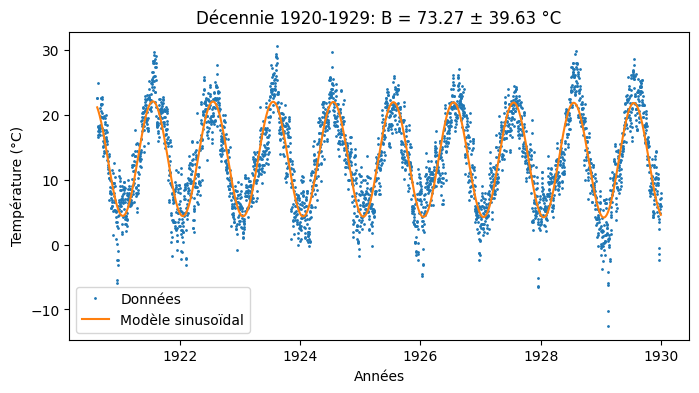

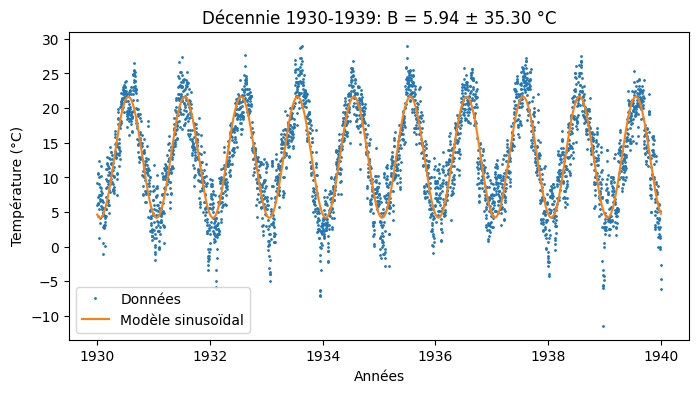

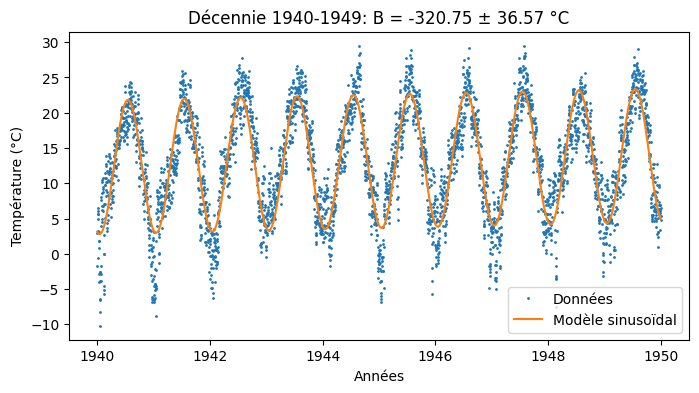

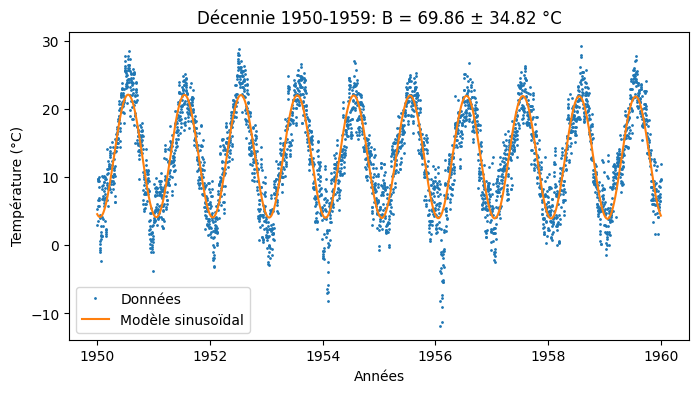

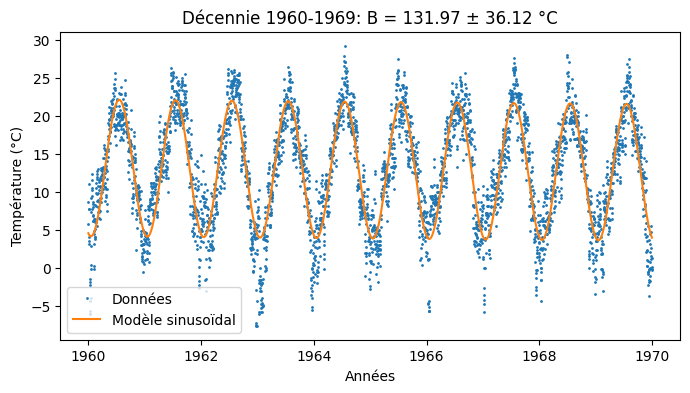

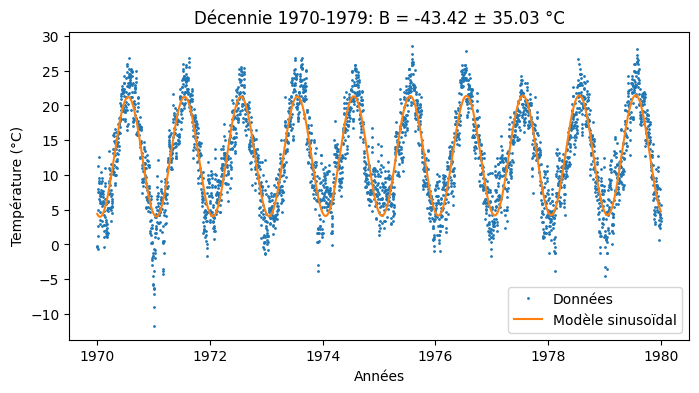

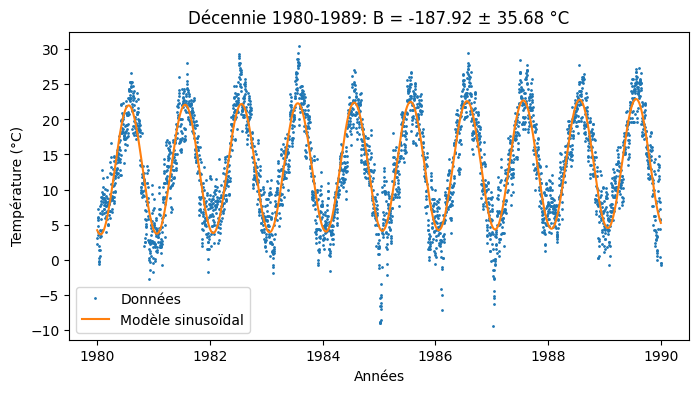

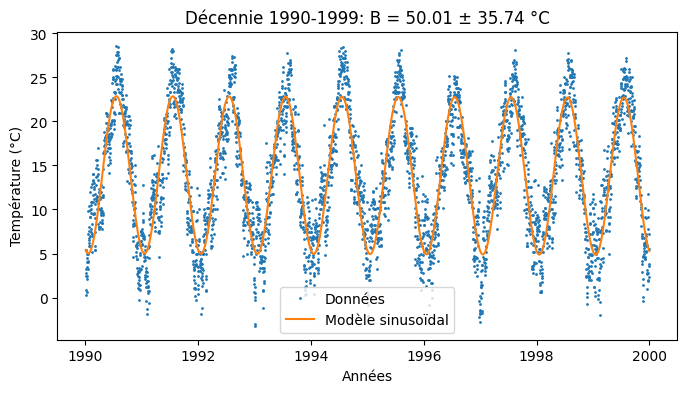

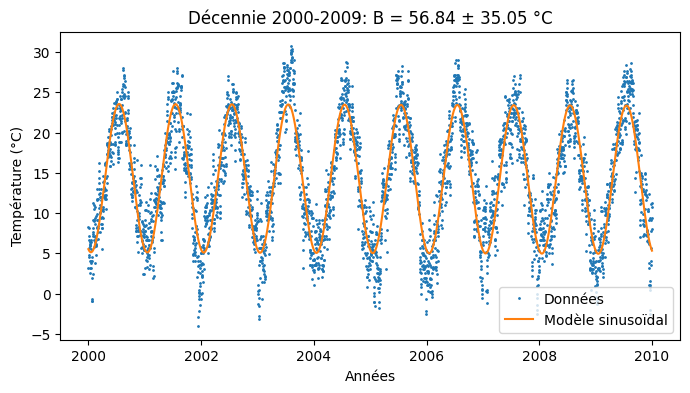

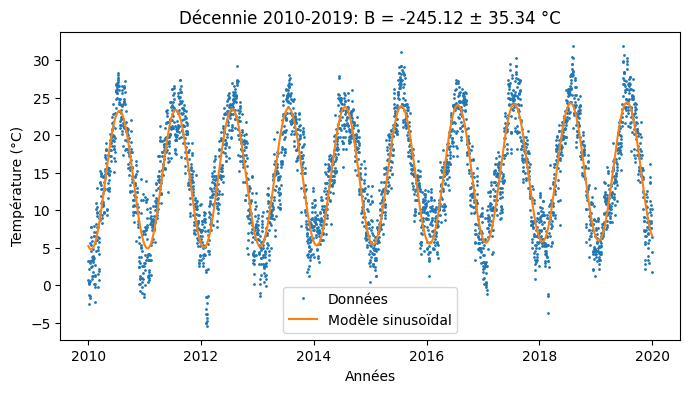

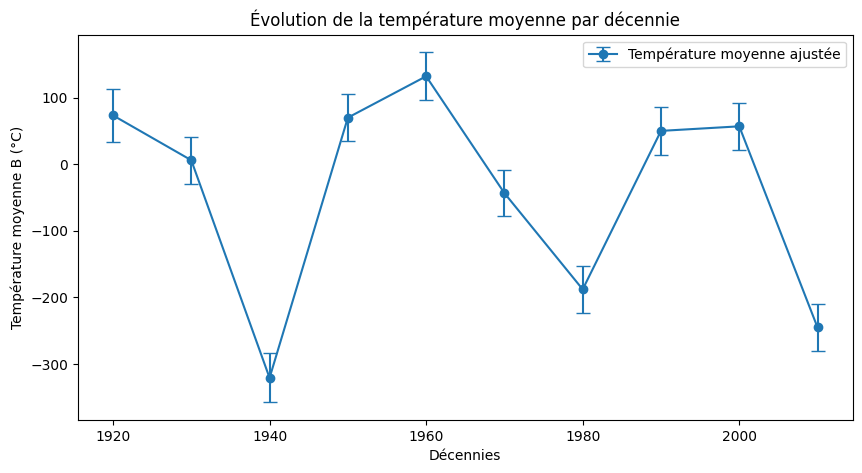

In [8]:
# On définit les décennies
decades = np.arange(int(annees.min() // 10 * 10), int(annees.max() // 10 * 10) + 10, 10)
B_values = []
B_errors = []

# Ajustement pour chaque décennie
for start in decades:
    mask = (annees >= start) & (annees < start + 10)
    if np.sum(mask) > 5:  # S'assurer qu'on a assez de points
        annees_decade = annees[mask]
        temperatures_decade = temperatures[mask]
        erreur = np.ones_like(temperatures_decade) * 5
        
        # Ajustement sinusoïdal
        params, covar = sc.curve_fit(modele, annees_decade, temperatures_decade, sigma=erreur)
        errors = np.sqrt(np.diag(covar))
        
        B_values.append(params[2])  # Température moyenne
        B_errors.append(errors[2])
        
        # Affichage
        plt.figure(figsize=(8, 4))
        plt.plot(annees_decade, temperatures_decade, '.', markersize=2, label="Données")
        plt.plot(annees_decade, modele(annees_decade, *params), label="Modèle sinusoïdal")
        plt.title(f"Décennie {start}-{start+9}: B = {params[2]:.2f} ± {errors[2]:.2f} °C")
        plt.xlabel("Années")
        plt.ylabel("Température (°C)")
        plt.legend()
        plt.show()

# Évolution de B au fil des décennies
plt.figure(figsize=(10, 5))
plt.errorbar(decades, B_values, yerr=B_errors, fmt='o-', capsize=5, label="Température moyenne ajustée")
plt.xlabel("Décennies")
plt.ylabel("Température moyenne B (°C)")
plt.title("Évolution de la température moyenne par décennie")
plt.legend()
plt.show()

Comme précédemment, on voit bien que l'ajustement sinusoïdal utilisé est correct et fit bien les données ce qui montre que le modèle est correcte. Néanmoins, on voit qu'il y a un gros soucis au niveau des ajustement avec la température moyenne, celle-ci est totalement fausse. En regardant les éléments du code indépendamment, on voit que le problème vient de l'ajustement curvefit mais je n'arrive pas à dire plus que ça.